# Churn EDA — Initial Data Review (Proxy CRM Dataset)
## 1. Project Context and Analysis Objectives
This notebook documents the initial data review and exploratory analysis for a simulated customer churn analytics project in the New Zealand telecommunications sector.

Due to the commercial sensitivity of real customer-level CRM data in New Zealand, a publicly available fictional dataset is used as a proxy. The analysis focuses on replicating the analytical reasoning, workflow, and decision support process that would typically be applied within a telecom organisation when addressing customer churn.

## 2. Data Input and Initial Inspection
This section loads the proxy dataset and performs an initial inspection to confirm successful ingestion and basic structural properties of the data.

### 2.1 Data Loading

The dataset is stored locally to ensure reproducibility and consistency across analytical environments.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings for easier inspection
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

# Load dataset from the same directory as this notebook
df = pd.read_csv("telco_churn_data.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (7043, 46)


,Customer ID,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Regular Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,City,Zip Code,Latitude,Longitude,Population,Churn Value,CLTV,Churn Category,Churn Reason,Total Customer Svc Requests,Product/Service Issues Reported,Customer Satisfaction
0,8779-QRDMV,No,0,1,NaN,No,0.00,No,Yes,Fiber Optic,9,No,No,Yes,No,No,Yes,No,No,Month-to-Month,Yes,Bank Withdrawal,41.236,39.65,0.00,0.0,0.00,Male,78,No,Yes,No,No,0,Los Angeles,90022,34.023810,-118.156582,68701,1,5433,Competitor,Competitor offered more data,5,0,NaN
1,7495-OOKFY,Yes,1,8,Offer E,Yes,48.85,Yes,Yes,Cable,19,No,Yes,No,No,No,No,No,No,Month-to-Month,Yes,Credit Card,83.876,633.30,0.00,120.0,390.80,Female,74,No,Yes,Yes,Yes,1,Los Angeles,90063,34.044271,-118.185237,55668,1,5302,Competitor,Competitor made better offer,5,0,NaN
2,1658-BYGOY,No,0,18,Offer D,Yes,11.33,Yes,Yes,Fiber Optic,57,No,No,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,99.268,1752.55,45.61,0.0,203.94,Male,71,No,Yes,No,Yes,3,Los Angeles,90065,34.108833,-118.229715,47534,1,3179,Competitor,Competitor made better offer,1,0,NaN
3,4598-XLKNJ,Yes,1,25,Offer C,Yes,19.76,No,Yes,Fiber Optic,13,No,Yes,Yes,No,Yes,Yes,No,No,Month-to-Month,Yes,Bank Withdrawal,102.440,2514.50,13.43,327.0,494.00,Female,78,No,Yes,Yes,Yes,1,Inglewood,90303,33.936291,-118.332639,27778,1,5337,Dissatisfaction,Limited range of services,1,1,2.0
4,4846-WHAFZ,Yes,1,37,Offer C,Yes,6.33,Yes,Yes,Cable,15,No,No,No,No,No,No,No,No,Month-to-Month,Yes,Bank Withdrawal,79.560,2868.15,0.00,430.0,234.21,Female,80,No,Yes,Yes,Yes,1,Whittier,90602,33.972119,-118.020188,26265,1,2793,Price,Extra data charges,1,0,2.0


### 2.2 Dataset Dimensions
The dataset contains 7,043 customer records and 46 variables.

Each row represents a unique customer, with attributes covering
customer tenure, service subscriptions, pricing indicators,
and behavioural proxies relevant to churn analysis.


## 3. Target Definition and Leakage Control
Before proceeding with feature analysis, churn-related fields are reviewed to define a valid predictive target and prevent data leakage.

### 3.1 Identification of Churn-Related Fields

In [40]:
# Identify churn-related column(s)
[c for c in df.columns if "churn" in c.lower()]

['Churn Value', 'Churn Category', 'Churn Reason']

### 3.2 Predictive Target Selection
For predictive modelling, a single binary outcome is required.

- **Churn Value** is used as the modelling target.
- Other churn-related fields represent post-churn information.


In [41]:
TARGET_COL = "Churn Value"


### 3.3 Data Leakage Considerations
Churn Category and Churn Reason contain information that would only be known
after a customer has already churned.

Including these fields during feature analysis or modelling would introduce
data leakage and result in unrealistic model performance.


In [42]:
leakage_cols = [
    "Churn Category",
    "Churn Reason"
]


## 4. Dataset Readiness and Quality Checks

#### 4.1 Schema and Data Types

A review of column data types is performed to confirm that variables
are represented in a form suitable for analysis and modelling.


In [43]:
# Column names and data types
column_inventory = (
    df.dtypes.astype(str)
    .to_frame("dtype")
    .reset_index()
    .rename(columns={"index": "column"})
    .sort_values(["dtype", "column"])
)

column_inventory



,column,dtype
6,Avg Monthly Long Distance Charges,float64
45,Customer Satisfaction,float64
36,Latitude,float64
37,Longitude,float64
22,Monthly Charge,float64
25,Total Extra Data Charges,float64
26,Total Long Distance Charges,float64
24,Total Refunds,float64
23,Total Regular Charges,float64
28,Age,int64


#### 4.2 Missing Values

Missing values are assessed to identify fields that may require
imputation, exclusion, or special treatment during modelling.


In [44]:
df.isna().sum().sort_values(ascending=False)


Customer Satisfaction                5209
Churn Category                       5174
Churn Reason                         5174
Offer                                3877
Internet Type                        1526
Referred a Friend                       0
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                        0
Avg Monthly GB Download                 0
Number of Referrals                     0
Tenure in Months                        0
Customer ID                             0
Device Protection Plan                  0
Online Backup                           0
Online Security                         0
Premium Tech Support                    0
Unlimited Data                          0
Streaming TV                            0
Streaming Movies                        0
Streaming Music                         0
Monthly Charge                          0
Total Regular Charges             

#### 4.3 Duplicate Records

Duplicate records are checked to ensure each row represents
a unique customer.


In [45]:
df.duplicated().sum()

np.int64(0)

#### 4.4 Initial Data Quality Observations

The dataset demonstrates characteristics consistent with a customer-level telecommunications CRM extract and is suitable for exploratory analysis and predictive modelling.

From a structural perspective, all records represent unique customers, with no duplicated rows detected. Column data types are broadly aligned with business expectations, combining categorical service attributes, numerical usage indicators, and billing-related measures. No structural anomalies are observed that would prevent downstream analysis.

Several distinct patterns of missing values are present in the dataset. Churn Category and Churn Reason are populated only for customers who have already churned and therefore represent post-churn information. These fields are excluded entirely from feature analysis and predictive modelling to prevent data leakage and ensure realistic model behaviour.

Other variables, including Customer Satisfaction, Offer, and Internet Type, exhibit conditional missingness. In a real-world CRM context, this typically reflects attributes that are only applicable to specific customer segments, such as survey participants, customers on promotional plans, or customers subscribed to internet services. This form of missingness is considered informative rather than erroneous and is preserved for explicit handling during feature engineering.

From a modelling and feature engineering perspective, different treatment strategies are applied based on the nature of missingness. Post-churn fields are removed from the modelling dataset, while conditionally missing fields are retained and may be transformed through explicit indicators or aligned with related service availability variables.

Importantly, core behavioural, contract, and billing-related variables show no missing values. This indicates that the dataset provides a sufficiently complete foundation for analysing churn drivers and supports progression to feature screening and model development, provided that missingness is handled explicitly in subsequent stages.


## 5. Feature Inventory and Initial Screening
The dataset contains 46 customer-level variables covering contract structure, pricing, service configuration, usage behaviour, and customer interactions. The following review organises available features by business domain and identifies variables most relevant for churn analysis.

### 5.1 Feature Eligibility for Pre-Churn Analysis

This section reviews the remaining customer-level variables to confirm their suitability for pre-churn analysis. Only attributes that would be observable prior to a customer leaving are considered eligible for downstream exploratory analysis.

All identifier fields and post-outcome attributes have already been excluded in earlier sections. The remaining variables represent customer tenure, service configuration, pricing exposure, usage behaviour, and interaction history that could reasonably inform churn risk assessment.


In [46]:
# Candidate feature set (after exclusions already defined earlier)
feature_cols = [
    c for c in df.columns
    if c not in ["Customer ID", TARGET_COL] + leakage_cols
]

len(feature_cols)


42

### 5.2 Business-Domain Feature Organisation

To support interpretation and prioritisation, features are grouped by business domain rather than by technical data type. This reflects how churn drivers are typically reviewed across commercial, product, and customer operations teams.


In [47]:
feature_groups = {
    "Contract & Tenure": [
        "Contract",
        "Tenure in Months",
        "Offer"
    ],
    "Pricing & Billing": [
        "Monthly Charge",
        "Total Regular Charges",
        "Total Refunds",
        "Total Extra Data Charges",
        "Total Long Distance Charges",
        "Avg Monthly Long Distance Charges",
        "Paperless Billing",
        "Payment Method"
    ],
    "Service Portfolio": [
        "Phone Service",
        "Multiple Lines",
        "Internet Service",
        "Internet Type",
        "Unlimited Data"
    ],
    "Value-Added Services": [
        "Online Security",
        "Online Backup",
        "Device Protection Plan",
        "Premium Tech Support"
    ],
    "Usage & Engagement": [
        "Avg Monthly GB Download",
        "Streaming TV",
        "Streaming Movies",
        "Streaming Music"
    ],
    "Customer Interaction & Issues": [
        "Total Customer Svc Requests",
        "Product/Service Issues Reported",
        "Number of Referrals",
        "Referred a Friend",
        "Customer Satisfaction"
    ],
    "Demographics & Household": [
        "Age",
        "Gender",
        "Married",
        "Senior Citizen",
        "Under 30",
        "Dependents",
        "Number of Dependents"
    ],
    "Geographic & Location": [
        "City",
        "Zip Code",
        "Latitude",
        "Longitude",
        "Population"
    ],
    "Customer Value": [
        "CLTV"
    ]
}

covered_features = sum(feature_groups.values(), [])
set(feature_cols) - set(covered_features)


set()

### 5.3 Initial Feature Screening Considerations

At this stage, no features are removed based on statistical criteria alone. Instead, screening decisions are guided by business plausibility and data availability prior to churn.

Key considerations include:
- whether the variable is observable before churn
- whether the variable plausibly influences customer retention behaviour
- whether the variable is actionable from a commercial or operational perspective

Variables failing these criteria may be deprioritised in later stages, even if they exhibit statistical correlation.


In [48]:
# Quick overview of feature data types
df[feature_cols].dtypes.value_counts()


object     23
int64      10
float64     9
Name: count, dtype: int64

### 5.4 Transition to Deep-Dive EDA

Based on the initial screening, subsequent analysis will focus on:
- tenure, contract type, and pricing structure
- service portfolio composition and optional add-ons
- usage intensity and engagement indicators
- customer interaction signals such as service requests and satisfaction

The next section conducts targeted exploratory analysis on these groups to identify early churn signals and inform feature engineering and modelling decisions.


## 6. Exploratory Analysis by Feature Domain

Following the initial feature inventory and screening, this section conducts targeted exploratory analysis across key business domains to examine how pre-churn observable attributes relate to customer churn outcomes.

Analysis is structured according to the previously defined feature groups, reflecting how churn drivers are typically reviewed by strategy, product, pricing, and customer operations teams in a telecommunications context.

The objective of this section is not model optimisation, but to identify:

- early churn signals observable prior to customer departure  
- meaningful distributional differences between churned and retained customers  
- candidate features suitable for downstream feature engineering and modelling  

Churn Value is used strictly as a reference outcome to support interpretation.


### 6.1 Churn Baseline

In [49]:
# 6.1 Churn Baseline Overview

churn_rate = df[TARGET_COL].mean()
churn_rate


np.float64(0.2653698707936959)

In [50]:
df[TARGET_COL].value_counts()


Churn Value
0    5174
1    1869
Name: count, dtype: int64

## 6.2 Contract & Tenure

Contract structure and customer tenure are consistently among the strongest structural drivers of churn in telecommunications.

From a commercial perspective, contract type affects switching friction, while tenure reflects relationship maturity and accumulated switching costs.


In [51]:
# Churn rate by contract type
contract_churn = (
    df.groupby("Contract")[TARGET_COL]
      .mean()
      .reset_index()
      .rename(columns={TARGET_COL: "Churn Rate"})
      .sort_values("Churn Rate", ascending=False)
)

contract_churn


,Contract,Churn Rate
0,Month-to-Month,0.458449
1,One Year,0.107097
2,Two Year,0.025491


In [52]:
# Contract vs churn (row-normalised)
pd.crosstab(df["Contract"], df[TARGET_COL], normalize="index")


Churn Value,0,1
Contract,,
Month-to-Month,0.541551,0.458449
One Year,0.892903,0.107097
Two Year,0.974509,0.025491


<Figure size 640x480 with 0 Axes>

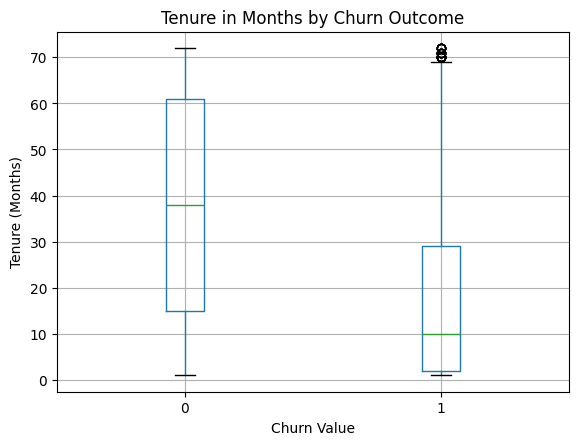

In [53]:
# Tenure distribution by churn
plt.figure()
df.boxplot(column="Tenure in Months", by=TARGET_COL)
plt.title("Tenure in Months by Churn Outcome")
plt.suptitle("")
plt.xlabel("Churn Value")
plt.ylabel("Tenure (Months)")
plt.show()


C:\Users\liyan\AppData\Local\Temp\ipykernel_5684\2872644507.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_tenure = df.groupby(tenure_bins)[TARGET_COL].mean()


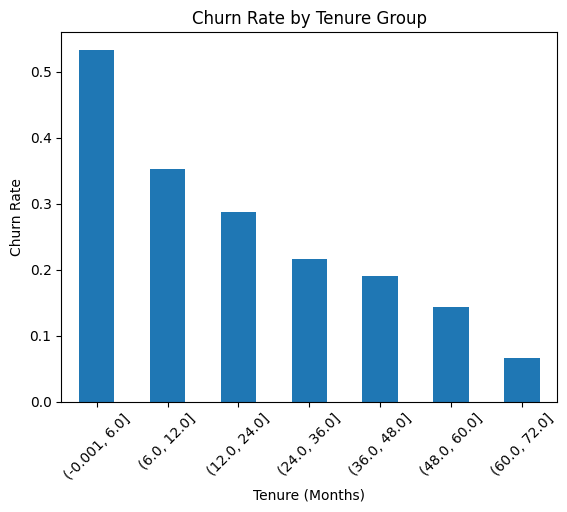

In [54]:
# Compute churn rate by tenure bins
tenure_bins = pd.cut(
    df["Tenure in Months"],
    bins=[0, 6, 12, 24, 36, 48, 60, 72],
    include_lowest=True
)

churn_by_tenure = df.groupby(tenure_bins)[TARGET_COL].mean()

# Plot churn rate by tenure bins
plt.figure()
churn_by_tenure.plot(kind="bar")
plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure (Months)")
plt.ylabel("Churn Rate")
plt.xticks(rotation=45)
plt.show()

## 6.3 Pricing & Billing Exposure

Pricing and billing variables capture both absolute cost levels and exposure
to usage-based or unexpected charges.

In a mature telecommunications market, churn is often driven less by headline
price and more by perceived value, bill volatility, and billing-related friction.


In [55]:
pricing_domain = feature_groups["Pricing & Billing"]
pricing_numeric_cols = [
    c for c in pricing_domain
    if c not in ["Paperless Billing", "Payment Method"]
]


df.groupby(TARGET_COL)[pricing_numeric_cols].mean()


,Monthly Charge,Total Regular Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Avg Monthly Long Distance Charges
Churn Value,,,,,,
0,61.265124,2550.792103,2.122279,275.935481,862.952107,22.883572
1,77.369727,1531.796094,1.518983,285.596501,433.917549,23.167635


<Figure size 640x480 with 0 Axes>

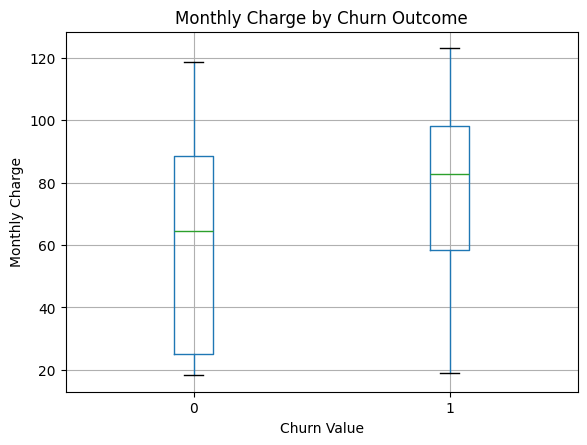

In [56]:
plt.figure()
df.boxplot(column="Monthly Charge", by=TARGET_COL)
plt.title("Monthly Charge by Churn Outcome")
plt.suptitle("")
plt.xlabel("Churn Value")
plt.ylabel("Monthly Charge")
plt.show()


<Figure size 640x480 with 0 Axes>

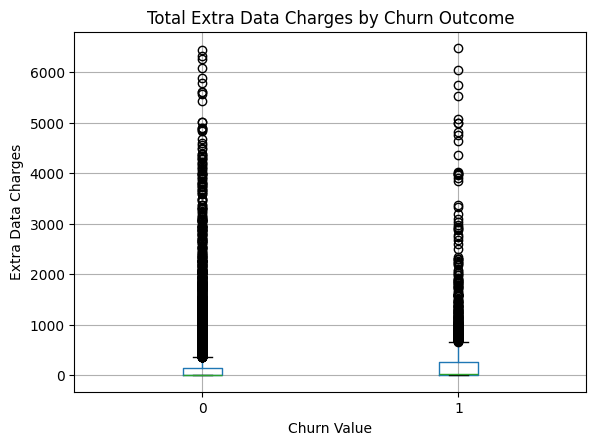

In [57]:
plt.figure()
df.boxplot(column="Total Extra Data Charges", by=TARGET_COL)
plt.title("Total Extra Data Charges by Churn Outcome")
plt.suptitle("")
plt.xlabel("Churn Value")
plt.ylabel("Extra Data Charges")
plt.show()


In [58]:
paperless_churn = (
    df.groupby("Paperless Billing")[TARGET_COL]
      .mean()
      .reset_index()
      .rename(columns={TARGET_COL: "Churn Rate"})
      .sort_values("Churn Rate", ascending=False)
)

paperless_churn



,Paperless Billing,Churn Rate
1,Yes,0.335651
0,No,0.163301


In [59]:
payment_method_churn = (
    df.groupby("Payment Method")[TARGET_COL]
      .mean()
      .reset_index()
      .rename(columns={TARGET_COL: "Churn Rate"})
      .sort_values("Churn Rate", ascending=False)
)

payment_method_churn

,Payment Method,Churn Rate
2,Mailed Check,0.368831
0,Bank Withdrawal,0.339985
1,Credit Card,0.144780


## 6.4 Service Portfolio & Optional Add-Ons

Service configuration reflects both product complexity and customer dependency. Customers subscribed to multiple services or optional add-ons typically face higher switching costs.


In [60]:
internet_service_churn = (
    df.groupby("Internet Service")[TARGET_COL]
      .mean()
      .reset_index()
      .rename(columns={TARGET_COL: "Churn Rate"})
      .sort_values("Churn Rate", ascending=False)
)

internet_service_churn



,Internet Service,Churn Rate
1,Yes,0.318289
0,No,0.074050


In [61]:
internet_type_churn = (
    df.assign(
        InternetType_filled=df["Internet Type"].fillna("No Internet")
    )
    .groupby("InternetType_filled")[TARGET_COL]
    .mean()
    .reset_index()
    .rename(columns={TARGET_COL: "Churn Rate"})
    .sort_values("Churn Rate", ascending=False)
)

internet_type_churn


,InternetType_filled,Churn Rate
0,Cable,0.516171
1,DSL,0.312500
2,Fiber Optic,0.189000
3,No Internet,0.074050


In [62]:
core_services = feature_groups["Service Portfolio"]

service_churn = (
    df.groupby("service_count")[TARGET_COL]
      .mean()
      .reset_index()
      .rename(columns={TARGET_COL: "Churn Rate"})
)

service_churn


KeyError: 'service_count'

In [ ]:
addon_cols = feature_groups["Value-Added Services"]


addon_churn = []

for col in addon_cols:
    temp = (
        df.groupby(col)[TARGET_COL]
          .mean()
          .reset_index()
          .rename(columns={col: "Subscribed", TARGET_COL: "Churn Rate"})
    )
    temp["Service"] = col
    addon_churn.append(temp)

addon_churn_df = pd.concat(addon_churn, ignore_index=True)

addon_churn_df


,Subscribed,Churn Rate,Service
0,No,0.313296,Online Security
1,Yes,0.146112,Online Security
2,No,0.291721,Online Backup
3,Yes,0.215315,Online Backup
4,No,0.286518,Device Protection Plan
5,Yes,0.225021,Device Protection Plan
6,No,0.311862,Premium Tech Support
7,Yes,0.151663,Premium Tech Support


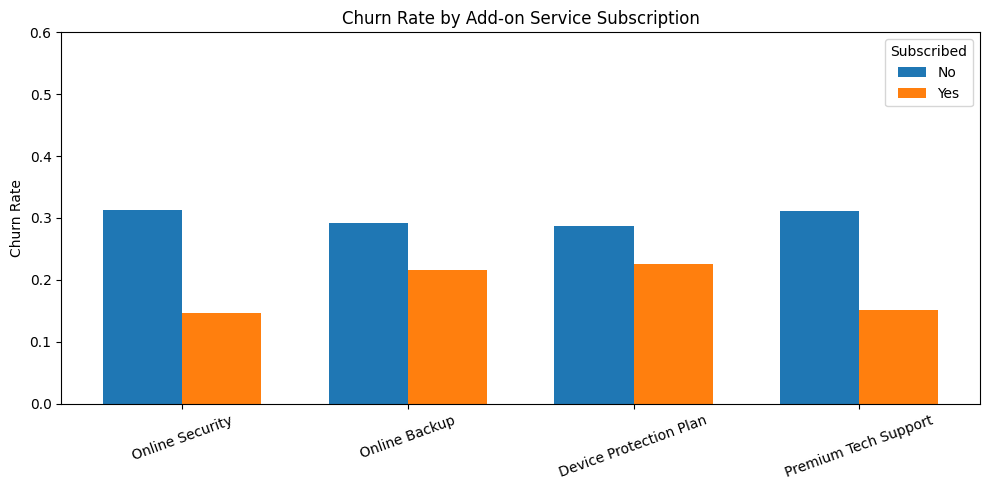

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

services = addon_churn_df["Service"].unique()
x = np.arange(len(services))
width = 0.35

churn_no = (
    addon_churn_df[addon_churn_df["Subscribed"] == "No"]
    .set_index("Service")
    .loc[services]["Churn Rate"]
)

churn_yes = (
    addon_churn_df[addon_churn_df["Subscribed"] == "Yes"]
    .set_index("Service")
    .loc[services]["Churn Rate"]
)

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, churn_no, width, label="No")
plt.bar(x + width/2, churn_yes, width, label="Yes")

plt.xticks(x, services, rotation=20)
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Add-on Service Subscription")
plt.ylim(0, 0.6)
plt.legend(title="Subscribed")
plt.tight_layout()
plt.show()




## 6.5 Usage & Engagement Indicators

Usage behaviour provides early signals of customer engagement or disengagement
prior to churn.

Customers extracting limited value from their subscribed services may be more
likely to re-evaluate their provider.


In [ ]:
churn_monthly_download = (
    df.groupby(TARGET_COL)["Avg Monthly GB Download"]
      .mean()
      .reset_index()
      .rename(columns={"Avg Monthly GB Download": "Average Monthly Download"})
)
churn_monthly_download

,Churn Value,Average Monthly Download
0,0,19.915733
1,1,24.419476


<Figure size 640x480 with 0 Axes>

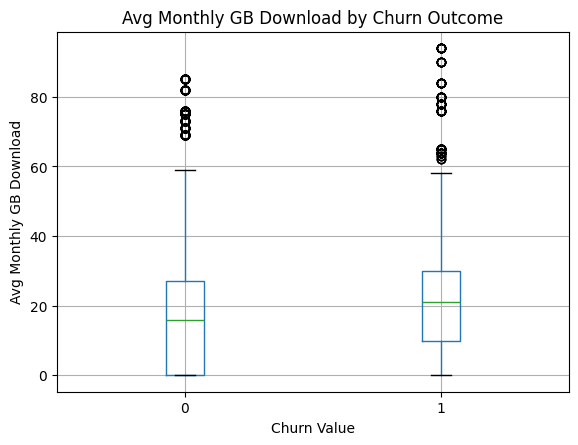

In [ ]:
plt.figure()
df.boxplot(column="Avg Monthly GB Download", by=TARGET_COL)
plt.title("Avg Monthly GB Download by Churn Outcome")
plt.suptitle("")
plt.xlabel("Churn Value")
plt.ylabel("Avg Monthly GB Download")
plt.show()


In [ ]:
stream_cols = [
    c for c in feature_groups["Usage & Engagement"]
    if c.startswith("Streaming")
]


stream_churn = []

for col in stream_cols:
    temp = (
        df.groupby(col)[TARGET_COL]
          .mean()
          .reset_index()
          .rename(columns={col: "Subscribed", TARGET_COL: "Churn Rate"})
    )
    temp["Service"] = col
    stream_churn.append(temp)

stream_churn_df = (
    pd.concat(stream_churn, ignore_index=True)
      .sort_values(["Service", "Churn Rate"], ascending=[True, False])
)

stream_churn_df = stream_churn_df[["Service", "Subscribed", "Churn Rate"]]
stream_churn_df



,Service,Subscribed,Churn Rate
3,Streaming Movies,Yes,0.299414
2,Streaming Movies,No,0.243795
5,Streaming Music,Yes,0.292605
4,Streaming Music,No,0.250494
1,Streaming TV,Yes,0.300702
0,Streaming TV,No,0.243312


## 6.6 Customer Interaction & Friction Signals

Customer service interactions often represent reactive indicators of service
friction or dissatisfaction.

Repeated or unresolved issues can accumulate and increase the likelihood of
customer departure.


In [ ]:
interaction_cols = [
    c for c in feature_groups["Customer Interaction & Issues"]
    if c not in ["Referred a Friend", "Customer Satisfaction", "Number of Referrals"]
]

df.groupby(TARGET_COL)[interaction_cols].mean()


,Total Customer Svc Requests,Product/Service Issues Reported
Churn Value,,
0,0.877464,0.135872
1,2.615837,0.784912


<Figure size 640x480 with 0 Axes>

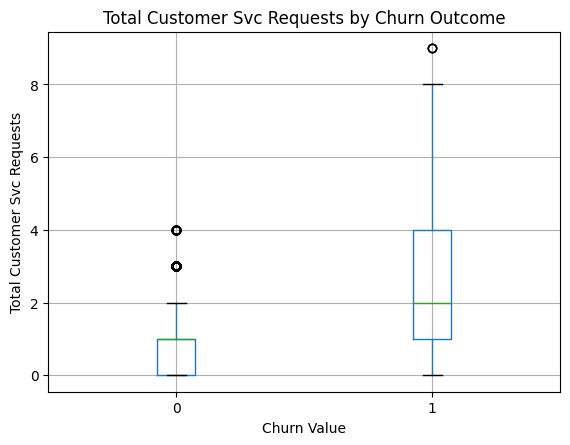

<Figure size 640x480 with 0 Axes>

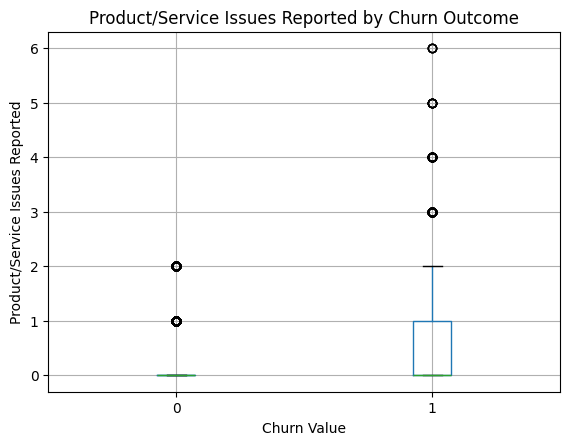

In [ ]:
for col in interaction_cols:
    plt.figure()
    df.boxplot(column=col, by=TARGET_COL)
    plt.title(f"{col} by Churn Outcome")
    plt.suptitle("")
    plt.xlabel("Churn Value")
    plt.ylabel(col)
    plt.show()


In [ ]:
# Customer Satisfaction (where available)
churn_customer_satisfaction = (
    df.groupby(TARGET_COL)["Customer Satisfaction"]
      .mean()
      .reset_index()
      .rename(columns={"Customer Satisfaction": "Average Customer Satisfaction"})
)
churn_customer_satisfaction


,Churn Value,Average Customer Satisfaction
0,0,3.758023
1,1,1.731278


### 6.7 Summary of Key Exploratory Insights

This exploratory analysis examined customer churn through multiple business lenses, including contract structure, tenure, pricing and billing exposure, service portfolio composition, usage behaviour, and customer interaction signals.

Across all dimensions, churn is shown to be a multi-factor outcome driven by both structural characteristics and experiential friction, rather than by price alone.

Several consistent patterns emerge.

First, relationship maturity is the strongest structural determinant of churn. Customers on month-to-month contracts and those with short tenure exhibit substantially higher churn rates, indicating low switching costs and limited customer-provider attachment. Conversely, long-tenure customers and those on multi-year contracts demonstrate strong retention, reflecting accumulated switching friction and perceived stability.

Second, pricing-related churn is driven more by billing volatility than by absolute price levels. Customers who churn tend to have higher monthly charges and greater exposure to extra data or variable usage fees. Paperless billing and certain payment methods are also associated with higher churn, suggesting that billing transparency, predictability, and perceived fairness play a critical role in retention decisions.

Third, service configuration and usage intensity reveal a non-linear relationship with churn. Customers with moderate numbers of subscribed services or higher usage levels exhibit elevated churn, likely due to increased sensitivity to service quality, pricing fairness, and comparative value. In contrast, customers with deeper service dependency—such as fibre-based internet or value-added service subscriptions—show lower churn, indicating stronger embeddedness within the service ecosystem.

Fourth, customer interaction and friction signals represent the most immediate indicators of churn risk. Customers who churn report significantly higher volumes of customer service requests and unresolved product or service issues. Customer satisfaction scores display a sharp divergence between churned and retained customers, reinforcing the role of accumulated dissatisfaction as a near-term driver of departure.

Overall, these findings indicate that churn risk arises from the interaction of weak structural ties, billing-related friction, service complexity, and unresolved customer experience issues. Importantly, many of these signals are observable prior to churn, making them suitable for predictive modelling and early intervention.

These insights directly inform the feature selection, transformation, and modelling strategy developed in the subsequent section.